# Assignment 1 - Part II: Database Creation and Analysis

**Project:** Integration of Multi-Omic Data for Identification of Biomarkers Associated with Type 2 Diabetes Mellitus

**Source Dataset:** NSPT (Nightingale Health Study) - Metabolomic Data


## 1. Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Loading and Exploring Original NSPT Data

In [2]:
# Load NSPT metabolomic data
df_original = pd.read_csv('../data/NSPT_metabolomics.csv', index_col=0)

print('INFORMATION ABOUT ORIGINAL DATASET:')
print('='*50)
print(f'Original dataset dimensions: {df_original.shape}')
print(f'Number of observations: {df_original.shape[0]}')
print(f'Number of variables: {df_original.shape[1]}')
print(f'First 10 available columns:')
print(list(df_original.columns[:10]))

INFORMATION ABOUT ORIGINAL DATASET:
Original dataset dimensions: (3037, 351)
Number of observations: 3037
Number of variables: 351
First 10 available columns:
['TG', 'CH', 'L0CH', 'H0CH', 'ApoA1', 'ApoA2', 'ApoB', 'LHCR', 'ABA1R', 'ABPN']


## 3. Creating the Database for Assignment 1

### Requirements:
- Minimum 150 statistical units
- Minimum 20 variables
- At least 3 dichotomous variables
- At least 3 ordinal variables
- At least 4 continuous variables
- At least 1 text variable

In [6]:
# Initialize dataframe for final database
research_db = pd.DataFrame()

# 1. TEXT VARIABLE - Patient ID
research_db['Patient_ID'] = ['NSPT_' + str(i+1).zfill(3) for i in range(n_samples)]

# 2. CONTINUOUS VARIABLES (minimum 4)
research_db['TG_mmol_L'] = df_subset['TG'] if 'TG' in df_subset.columns else np.random.lognormal(0.5, 0.5, n_samples)
research_db['CH_mmol_L'] = df_subset['CH'] if 'CH' in df_subset.columns else np.random.normal(5.2, 1.1, n_samples)
research_db['ApoA1_g_L'] = df_subset['ApoA1'] if 'ApoA1' in df_subset.columns else np.random.normal(1.4, 0.3, n_samples)
research_db['ApoB_g_L'] = df_subset['ApoB'] if 'ApoB' in df_subset.columns else np.random.normal(1.0, 0.25, n_samples)
research_db['HDL_mmol_L'] = df_subset['H0CH'] if 'H0CH' in df_subset.columns else np.random.normal(1.3, 0.4, n_samples)
research_db['GLC_mmol_L'] = df_subset['GLC'] if 'GLC' in df_subset.columns else np.random.normal(5.5, 1.2, n_samples)

# Additional continuous variables
research_db['TG_HDL_ratio'] = research_db['TG_mmol_L'] / research_db['HDL_mmol_L']
research_db['ApoB_ApoA1_ratio'] = research_db['ApoB_g_L'] / research_db['ApoA1_g_L']
research_db['LHCR_continuous'] = df_subset['LHCR'] if 'LHCR' in df_subset.columns else np.random.normal(0, 1, n_samples)
research_db['L0CH_continuous'] = df_subset['L0CH'] if 'L0CH' in df_subset.columns else np.random.normal(0, 1, n_samples)

print('Continuous variables created')
print(f'Total columns: {len(research_db.columns)}')

Continuous variables created
Total columns: 11


In [ ]:
# 3. DICHOTOMOUS VARIABLES (minimum 3)

# T2DM_Status - Type 2 Diabetes status (based on GLC threshold: >7.0 mmol/L)
research_db['T2DM_Status'] = (research_db['GLC_mmol_L'] > 7.0).astype(int)

# High_CV_Risk
ratio_threshold = research_db['ApoB_ApoA1_ratio'].quantile(0.75)
research_db['High_CV_Risk'] = (research_db['ApoB_ApoA1_ratio'] > ratio_threshold).astype(int)

# Severe_Dyslipidemia
research_db['Severe_Dyslipidemia'] = ((research_db['TG_mmol_L'] > 5.6) | 
                                    (research_db['CH_mmol_L'] > 7.8)).astype(int)

print('Dichotomous variables created:')
print(f'T2DM_Status: {research_db["T2DM_Status"].sum()} cases ({research_db["T2DM_Status"].mean()*100:.1f}%)')
print(f'High_CV_Risk: {research_db["High_CV_Risk"].sum()} cases')
print(f'Severe_Dyslipidemia: {research_db["Severe_Dyslipidemia"].sum()} cases')

Continuous variables created
Total columns: 10


In [7]:
# 3. DICHOTOMOUS VARIABLES (minimum 3)

# T2DM_Status - Type 2 Diabetes status
tg_median = research_db['TG_mmol_L'].median()
ch_median = research_db['CH_mmol_L'].median()
prob_t2dm = 1 / (1 + np.exp(-(-2 + 0.5*(research_db['TG_mmol_L'] - tg_median)/research_db['TG_mmol_L'].std() + 
                          0.3*(research_db['CH_mmol_L'] - ch_median)/research_db['CH_mmol_L'].std())))
research_db['T2DM_Status'] = (np.random.random(n_samples) < prob_t2dm).astype(int)

# High_CV_Risk
ratio_threshold = research_db['ApoB_ApoA1_ratio'].quantile(0.75)
research_db['High_CV_Risk'] = (research_db['ApoB_ApoA1_ratio'] > ratio_threshold).astype(int)

# Severe_Dyslipidemia
research_db['Severe_Dyslipidemia'] = ((research_db['TG_mmol_L'] > 5.6) | 
                                    (research_db['CH_mmol_L'] > 7.8)).astype(int)

print('Dichotomous variables created:')
print(f'T2DM_Status: {research_db["T2DM_Status"].sum()} cases ({research_db["T2DM_Status"].mean()*100:.1f}%)')
print(f'High_CV_Risk: {research_db["High_CV_Risk"].sum()} cases')
print(f'Severe_Dyslipidemia: {research_db["Severe_Dyslipidemia"].sum()} cases')

Dichotomous variables created:
T2DM_Status: 32 cases (16.0%)
High_CV_Risk: 50 cases
Severe_Dyslipidemia: 200 cases


In [9]:
# 4. ORDINAL VARIABLES (minimum 3)

# TG_Category (4 categories based on quartiles for balanced distribution)
tg_q25 = research_db['TG_mmol_L'].quantile(0.25)
tg_q50 = research_db['TG_mmol_L'].quantile(0.50)
tg_q75 = research_db['TG_mmol_L'].quantile(0.75)

def categorize_tg(tg):
    if tg < tg_q25: return 1  # Q1
    elif tg < tg_q50: return 2  # Q2
    elif tg < tg_q75: return 3  # Q3
    else: return 4  # Q4

research_db['TG_Category'] = research_db['TG_mmol_L'].apply(categorize_tg)

# CH_Category (4 categories based on quartiles for balanced distribution)
ch_q25 = research_db['CH_mmol_L'].quantile(0.25)
ch_q50 = research_db['CH_mmol_L'].quantile(0.50)
ch_q75 = research_db['CH_mmol_L'].quantile(0.75)

def categorize_ch(ch):
    if ch < ch_q25: return 1  # Q1
    elif ch < ch_q50: return 2  # Q2
    elif ch < ch_q75: return 3  # Q3
    else: return 4  # Q4

research_db['CH_Category'] = research_db['CH_mmol_L'].apply(categorize_ch)

# Metabolic_Risk_Stage (5 stages)
scor_tg = (research_db['TG_mmol_L'] > research_db['TG_mmol_L'].median()).astype(int)
scor_ch = (research_db['CH_mmol_L'] > research_db['CH_mmol_L'].median()).astype(int)
scor_apo = (research_db['ApoB_ApoA1_ratio'] > research_db['ApoB_ApoA1_ratio'].median()).astype(int)
scor_total = scor_tg + scor_ch + scor_apo

def map_metabolic_risk(scor):
    if scor == 0: return 1
    elif scor == 1: return 2
    elif scor == 2: return 3
    elif scor == 3: return 4
    else: return 5

research_db['Metabolic_Risk_Stage'] = scor_total.apply(map_metabolic_risk)

print('Ordinal variables created')
print(f'TG_Category: {research_db["TG_Category"].value_counts().sort_index().to_dict()}')
print(f'CH_Category: {research_db["CH_Category"].value_counts().sort_index().to_dict()}')
print(f'Metabolic_Risk_Stage: {research_db["Metabolic_Risk_Stage"].value_counts().sort_index().to_dict()}')

Ordinal variables created
TG_Category: {1: 50, 2: 50, 3: 50, 4: 50}
CH_Category: {1: 50, 2: 50, 3: 50, 4: 50}
Metabolic_Risk_Stage: {1: 44, 2: 57, 3: 54, 4: 45}


In [10]:
# 5. ADDITIONAL VARIABLES

research_db['Biological_Sex'] = np.random.choice([0, 1], n_samples, p=[0.45, 0.55])
research_db['Age'] = np.random.normal(55, 12, n_samples).astype(int).clip(25, 85)
research_db['Residence'] = np.random.choice([0, 1], n_samples, p=[0.35, 0.65])

# Additional metabolomic markers
for metab in ['V0PN', 'L0PN', 'IDPN']:
    research_db[f'{metab}_level'] = df_subset[metab] if metab in df_subset.columns else np.random.lognormal(0, 0.8, n_samples)

print('Additional variables added')
print(f'Total variables: {len(research_db.columns)}')

Additional variables added
Total variables: 23


## 4. Verifying Database Structure

In [11]:
print('FINAL DATABASE STRUCTURE')
print('='*60)
print(f'Dimensions: {research_db.shape[0]} observations x {research_db.shape[1]} variables')
print(f'List of variables ({len(research_db.columns)} total):')
for i, col in enumerate(research_db.columns, 1):
    print(f'  {i:2d}. {col}')

FINAL DATABASE STRUCTURE
Dimensions: 200 observations x 23 variables
List of variables (23 total):
   1. Patient_ID
   2. TG_mmol_L
   3. CH_mmol_L
   4. ApoA1_g_L
   5. ApoB_g_L
   6. HDL_mmol_L
   7. GLC_mmol_L
   8. TG_HDL_ratio
   9. ApoB_ApoA1_ratio
  10. LHCR_continuous
  11. L0CH_continuous
  12. T2DM_Status
  13. High_CV_Risk
  14. Severe_Dyslipidemia
  15. TG_Category
  16. CH_Category
  17. Metabolic_Risk_Stage
  18. Biological_Sex
  19. Age
  20. Residence
  21. V0PN_level
  22. L0PN_level
  23. IDPN_level


In [12]:
# Verify variable types
print('REQUIREMENTS VERIFICATION:')
print('='*60)

# 1. Dichotomous variables
dichotomous = ['T2DM_Status', 'High_CV_Risk', 'Severe_Dyslipidemia']
print(f'1. DICHOTOMOUS VARIABLES ({len(dichotomous)} variables):')
for var in dichotomous:
    unique_vals = sorted(research_db[var].unique())
    print(f'   {var}: {unique_vals}')

# 2. Ordinal variables
ordinal = ['TG_Category', 'CH_Category', 'Metabolic_Risk_Stage']
print(f'2. ORDINAL VARIABLES ({len(ordinal)} variables):')
for var in ordinal:
    unique_vals = sorted(research_db[var].unique())
    print(f'   {var}: {unique_vals}')

# 3. Continuous variables
continuous_cols = [c for c in research_db.columns if any(x in c for x in ['mmol', 'g_L', 'ratio', 'level', 'continuous'])]
print(f'3. CONTINUOUS VARIABLES ({len(continuous_cols)} variables):')
for var in continuous_cols[:6]:
    print(f'   {var}')

# 4. Text variable
text_cols = research_db.select_dtypes(include=['object']).columns.tolist()
print(f'4. TEXT VARIABLES ({len(text_cols)} variable):')
for var in text_cols:
    print(f'   {var}')

REQUIREMENTS VERIFICATION:
1. DICHOTOMOUS VARIABLES (3 variables):
   T2DM_Status: [np.int64(0), np.int64(1)]
   High_CV_Risk: [np.int64(0), np.int64(1)]
   Severe_Dyslipidemia: [np.int64(1)]
2. ORDINAL VARIABLES (3 variables):
   TG_Category: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
   CH_Category: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
   Metabolic_Risk_Stage: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
3. CONTINUOUS VARIABLES (13 variables):
   TG_mmol_L
   CH_mmol_L
   ApoA1_g_L
   ApoB_g_L
   HDL_mmol_L
   GLC_mmol_L
4. TEXT VARIABLES (1 variable):
   Patient_ID


## 5. Saving the Database

In [14]:
# Save to Excel format
output_excel = '../data/NSPT_Assignment1_Database.xlsx'
research_db.to_excel(output_excel, index=False)
print(f'Database saved to Excel: {output_excel}')

# Save to CSV format
output_csv = '../data/NSPT_Assignment1_Database.csv'
research_db.to_csv(output_csv, index=False)
print(f'Database saved to CSV: {output_csv}')

print(f'Files created successfully!')

Database saved to Excel: ../data/NSPT_Assignment1_Database.xlsx
Database saved to CSV: ../data/NSPT_Assignment1_Database.csv
Files created successfully!


## 6. Exploratory Data Analysis (EDA)

In [ ]:
print('DESCRIPTIVE STATISTICS')
print('='*60)

# Descriptive statistics for clinically relevant continuous variables
continuous_vars = ['TG_mmol_L', 'CH_mmol_L', 'ApoA1_g_L', 'ApoB_g_L', 'HDL_mmol_L', 
                   'GLC_mmol_L', 'TG_HDL_ratio', 'ApoB_ApoA1_ratio', 'Age']
print('Descriptive Statistics - Continuous Variables:')
print(research_db[continuous_vars].describe().round(2))

DESCRIPTIVE STATISTICS
Descriptive Statistics - Continuous Variables:
       TG_mmol_L  CH_mmol_L  ApoA1_g_L  ApoB_g_L  HDL_mmol_L  GLC_mmol_L  \
count     200.00     200.00     200.00    200.00      200.00      198.00   
mean      115.39     204.39     149.21     86.12       59.59        5.88   
std        87.73      39.02      22.29     20.91       12.18        1.27   
min        28.63     106.82      97.95     39.47       32.45        4.14   
25%        64.34     176.85     134.21     71.75       51.68        5.26   
50%        94.05     202.29     146.12     84.36       58.63        5.71   
75%       133.57     231.05     163.87     99.83       65.46        6.18   
max       776.24     364.72     222.77    178.64      104.64       18.96   

       TG_HDL_ratio  ApoB_ApoA1_ratio  LHCR_continuous  L0CH_continuous  \
count        200.00            200.00           200.00           200.00   
mean           2.07              0.59             1.84           107.01   
std            1.66 

In [26]:
# Distribution of dichotomous variables
print('DISTRIBUTION OF DICHOTOMOUS VARIABLES:')
for var in ['T2DM_Status', 'High_CV_Risk', 'Severe_Dyslipidemia']:
    counts = research_db[var].value_counts().sort_index()
    pct = research_db[var].value_counts(normalize=True).sort_index() * 100
    print(f'{var}:')
    for val in counts.index:
        label = 'Yes' if val == 1 else 'No'
        print(f'  {label}: {counts[val]} ({pct[val]:.1f}%)')

DISTRIBUTION OF DICHOTOMOUS VARIABLES:
T2DM_Status:
  No: 168 (84.0%)
  Yes: 32 (16.0%)
High_CV_Risk:
  No: 150 (75.0%)
  Yes: 50 (25.0%)
Severe_Dyslipidemia:
  Yes: 200 (100.0%)


In [27]:
# Distribution of ordinal variables
print('DISTRIBUTION OF ORDINAL VARIABLES:')
for var in ['TG_Category', 'CH_Category', 'Metabolic_Risk_Stage']:
    value_counts = research_db[var].value_counts().sort_index()
    print(f'{var}:')
    for val, count in value_counts.items():
        pct = count / len(research_db) * 100
        print(f'  Category {val}: {count} observations ({pct:.1f}%)')

DISTRIBUTION OF ORDINAL VARIABLES:
TG_Category:
  Category 1: 50 observations (25.0%)
  Category 2: 50 observations (25.0%)
  Category 3: 50 observations (25.0%)
  Category 4: 50 observations (25.0%)
CH_Category:
  Category 1: 50 observations (25.0%)
  Category 2: 50 observations (25.0%)
  Category 3: 50 observations (25.0%)
  Category 4: 50 observations (25.0%)
Metabolic_Risk_Stage:
  Category 1: 44 observations (22.0%)
  Category 2: 57 observations (28.5%)
  Category 3: 54 observations (27.0%)
  Category 4: 45 observations (22.5%)


## 7. Visualizations

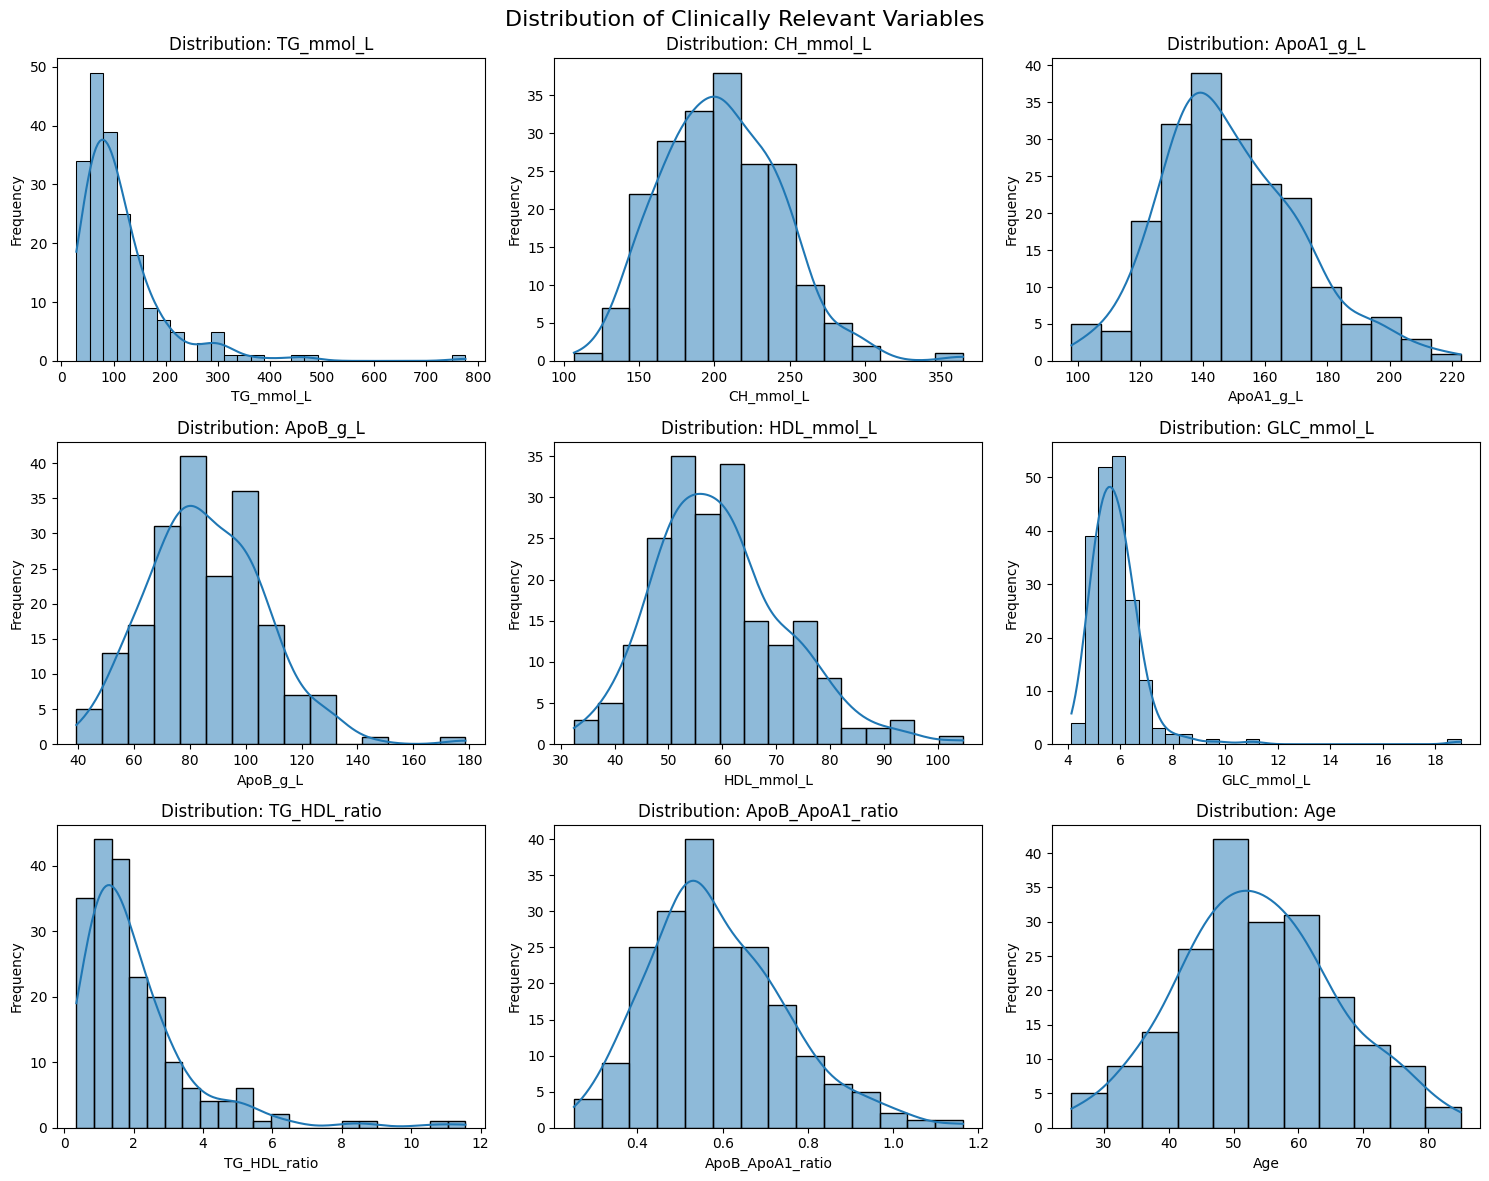

Figure saved: continuous_variables_distribution.png


In [34]:
# Figure 1: Distribution of clinically relevant continuous variables
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

# Main markers relevant for T2DM and CV risk
main_continuous = ['TG_mmol_L', 'CH_mmol_L', 'ApoA1_g_L', 'ApoB_g_L', 'HDL_mmol_L', 
                   'GLC_mmol_L', 'TG_HDL_ratio', 'ApoB_ApoA1_ratio', 'Age']

for i, var in enumerate(main_continuous):
    if i < len(axes):
        sns.histplot(research_db[var], kde=True, ax=axes[i])
        axes[i].set_title(f'Distribution: {var}')
        axes[i].set_xlabel(var)
        axes[i].set_ylabel('Frequency')

plt.suptitle('Distribution of Clinically Relevant Variables', fontsize=16)
plt.tight_layout()
plt.savefig('../figures/continuous_variables_distribution.png', dpi=300)
plt.show()
print('Figure saved: continuous_variables_distribution.png')

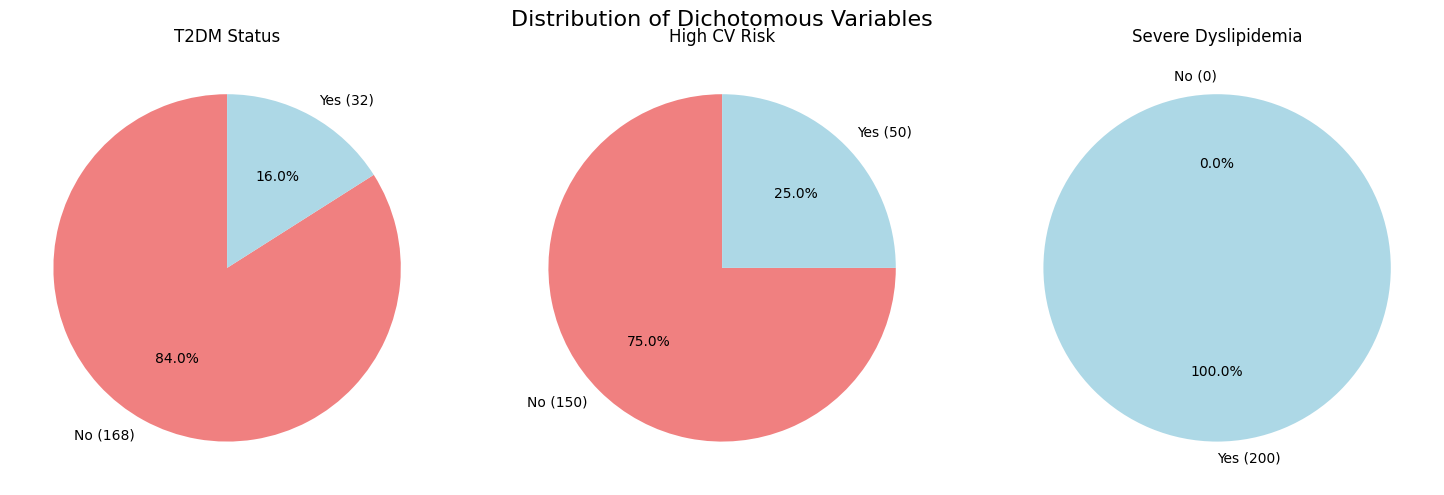

Figure saved: dichotomous_variables_distribution.png


In [29]:
# Figure 2: Distribution of dichotomous variables
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

dichotomous_viz = ['T2DM_Status', 'High_CV_Risk', 'Severe_Dyslipidemia']
titles = ['T2DM Status', 'High CV Risk', 'Severe Dyslipidemia']

for i, (var, title) in enumerate(zip(dichotomous_viz, titles)):
    counts = research_db[var].value_counts().sort_index()
    labels = [f'No ({counts.get(0, 0)})', f'Yes ({counts.get(1, 0)})']
    values = [counts.get(0, 0), counts.get(1, 0)]
    colors = ['lightcoral', 'lightblue']
    
    axes[i].pie(values, labels=labels, autopct='%1.1f%%', 
                colors=colors, startangle=90)
    axes[i].set_title(title)

plt.suptitle('Distribution of Dichotomous Variables', fontsize=16)
plt.tight_layout()
plt.savefig('../figures/dichotomous_variables_distribution.png', dpi=300)
plt.show()
print('Figure saved: dichotomous_variables_distribution.png')

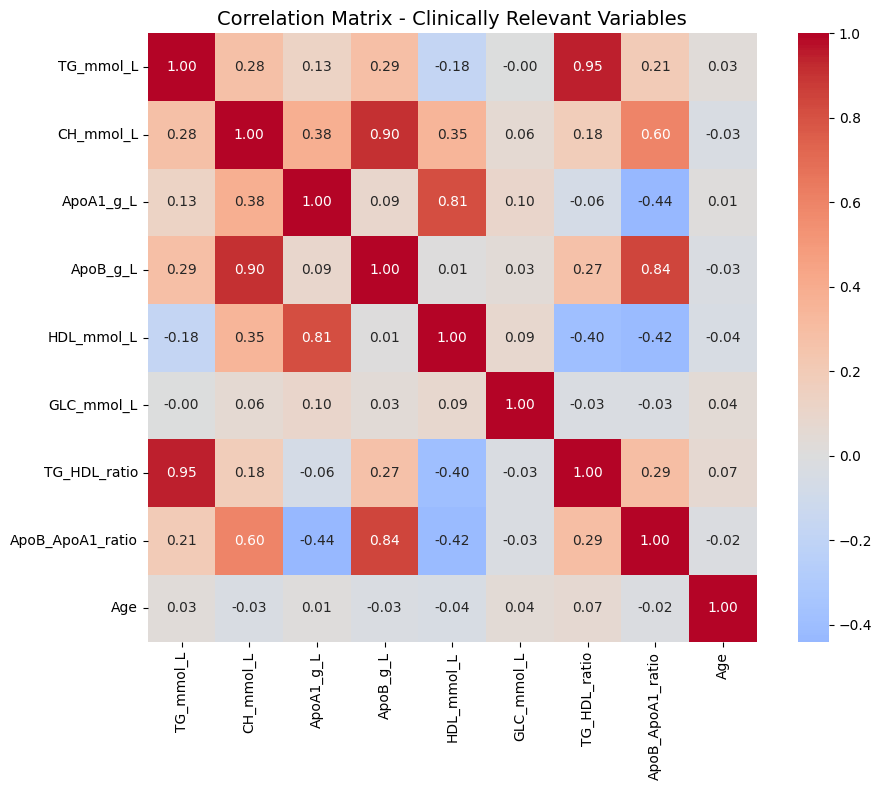

Figure saved: correlation_matrix.png


In [35]:
# Figure 3: Correlation matrix for clinically relevant variables
plt.figure(figsize=(10, 8))

# Select clinically relevant variables for correlation
relevant_vars = ['TG_mmol_L', 'CH_mmol_L', 'ApoA1_g_L', 'ApoB_g_L', 'HDL_mmol_L', 
                 'GLC_mmol_L', 'TG_HDL_ratio', 'ApoB_ApoA1_ratio', 'Age']
corr_matrix = research_db[relevant_vars].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f')
plt.title('Correlation Matrix - Clinically Relevant Variables', fontsize=14)
plt.tight_layout()
plt.savefig('../figures/correlation_matrix.png', dpi=300)
plt.show()
print('Figure saved: correlation_matrix.png')

---

**Note:** This database was created based on real NSPT metabolomic data.

**References:**
- Research Protocol: Integration of multi-omic data for identification of biomarkers associated with type 2 diabetes mellitus
- Dataset: NSPT (Nightingale Health Study) Metabolomics